# Model Training
## Museum Visitor Prediction — Melbourne Museum of Migration

We train and compare four approaches:
1. **Baselines** — naive mean & last-week carry-forward
2. **Random Forest** — ensemble of decision trees
3. **XGBoost** — gradient boosting
4. **Prophet** — Facebook time series model

Evaluation uses **TimeSeriesSplit** to respect temporal ordering (no data leakage).

In [1]:
# !pip install xgboost

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

# ── Load data & feature metadata ──────────────────────────────
df = pd.read_csv('../data/processed/museum_visitors_engineered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

with open('../data/processed/feature_meta.json') as f:
    meta = json.load(f)

ALL_FEATURES = [c for c in meta['all'] if c in df.columns]
TARGET       = meta['target_raw']   # 'visitors'
TARGET_LOG   = meta['target_log']   # 'visitors_log'

print(f"Rows: {len(df)}  |  Features: {len(ALL_FEATURES)}  |  Target: {TARGET}")

Rows: 1006  |  Features: 80  |  Target: visitors


## 1. Helper Functions

In [10]:
def regression_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true.clip(lower=1))) * 100
    if label:
        print(f"{label:30s}  MAE={mae:6.1f}  RMSE={rmse:6.1f}  R²={r2:.3f}  MAPE={mape:.1f}%")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


def ts_cv_score(model, X, y, n_splits=5, log_target=False):
    """Time-series cross-validation, returns mean metrics across folds."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_metrics = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        if log_target:
            preds = np.expm1(preds)
            y_val = np.expm1(y_val)
        fold_metrics.append(regression_metrics(y_val, preds))
    return pd.DataFrame(fold_metrics).mean().to_dict()


results = {}   # store all model results here
print("Helper functions ready.")

Helper functions ready.


## 2. Train / Test Split

Use the last **90 days** as hold-out test set; everything before is training data.

In [11]:
TEST_DAYS = 90
split_date = df['date'].max() - pd.Timedelta(days=TEST_DAYS)

train = df[df['date'] <= split_date].copy()
test  = df[df['date'] >  split_date].copy()

X_train = train[ALL_FEATURES]
y_train = train[TARGET]
y_train_log = train[TARGET_LOG]

X_test  = test[ALL_FEATURES]
y_test  = test[TARGET]

print(f"Train: {len(train)} rows  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test : {len(test)}  rows  ({test['date'].min().date()} → {test['date'].max().date()})")

Train: 916 rows  (2023-04-01 → 2025-10-02)
Test : 90  rows  (2025-10-03 → 2025-12-31)


## 3. Baseline Models

In [12]:
# Baseline 1: global mean
mean_pred = np.full(len(test), y_train.mean())
results['Baseline (mean)'] = regression_metrics(y_test, mean_pred, 'Baseline (mean)')

# Baseline 2: last-week carry-forward (lag_7)
lag7_pred = test['visitors_lag_7'].fillna(y_train.mean()).values \
    if 'visitors_lag_7' in test.columns \
    else test['visitors_last_week'].fillna(y_train.mean()).values
results['Baseline (last week)'] = regression_metrics(y_test, lag7_pred, 'Baseline (last week)')

# Baseline 3: 7-day rolling mean
roll7_pred = test['rolling_mean_7d'].fillna(y_train.mean()).values
results['Baseline (7d MA)'] = regression_metrics(y_test, roll7_pred, 'Baseline (7d MA)')

Baseline (mean)                 MAE= 143.9  RMSE= 189.8  R²=-0.685  MAPE=26.2%
Baseline (last week)            MAE= 125.0  RMSE= 162.5  R²=-0.235  MAPE=27.4%
Baseline (7d MA)                MAE= 119.3  RMSE= 152.7  R²=-0.091  MAPE=26.5%


## 4. Random Forest

In [13]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Running 5-fold time-series CV for Random Forest...")
rf_cv = ts_cv_score(rf, X_train, y_train, n_splits=5)
print(f"CV  →  MAE={rf_cv['MAE']:.1f}  RMSE={rf_cv['RMSE']:.1f}  R²={rf_cv['R2']:.3f}  MAPE={rf_cv['MAPE']:.1f}%")

# Final fit on all training data
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
results['Random Forest'] = regression_metrics(y_test, rf_preds, 'Random Forest (test)')

Running 5-fold time-series CV for Random Forest...
CV  →  MAE=78.2  RMSE=109.6  R²=0.426  MAPE=21.0%
Random Forest (test)            MAE=  78.4  RMSE= 103.7  R²=0.497  MAPE=16.3%


## 5. XGBoost

In [14]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print("Running 5-fold time-series CV for XGBoost...")
xgb_cv = ts_cv_score(xgb_model, X_train, y_train_log, n_splits=5, log_target=True)
print(f"CV  →  MAE={xgb_cv['MAE']:.1f}  RMSE={xgb_cv['RMSE']:.1f}  R²={xgb_cv['R2']:.3f}  MAPE={xgb_cv['MAPE']:.1f}%")

# Final fit on log-transformed target
xgb_model.fit(X_train, y_train_log)
xgb_preds = np.expm1(xgb_model.predict(X_test))
results['XGBoost'] = regression_metrics(y_test, xgb_preds, 'XGBoost (test)')

Running 5-fold time-series CV for XGBoost...
CV  →  MAE=71.0  RMSE=103.4  R²=0.480  MAPE=17.1%
XGBoost (test)                  MAE=  69.9  RMSE=  90.7  R²=0.616  MAPE=14.0%


## 6. Prophet

In [15]:
from prophet import Prophet

# Prophet expects columns: ds, y
prophet_train = train[['date', TARGET]].rename(columns={'date': 'ds', TARGET: 'y'})
prophet_test  = test[['date', TARGET]].rename(columns={'date': 'ds', TARGET: 'y'})

# Add regressors available at prediction time
extra_regressors = [
    'is_public_holiday', 'is_school_holiday', 'special_exhibition',
    'local_event', 'marketing_campaign', 'temperature', 'weather_encoded'
]
extra_regressors = [r for r in extra_regressors if r in df.columns]

for r in extra_regressors:
    prophet_train[r] = train[r].values
    prophet_test[r]  = test[r].values

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10
)
for r in extra_regressors:
    prophet_model.add_regressor(r)

print("Fitting Prophet...")
prophet_model.fit(prophet_train)

prophet_forecast = prophet_model.predict(prophet_test)
prophet_preds = prophet_forecast['yhat'].clip(lower=0).values
results['Prophet'] = regression_metrics(y_test, prophet_preds, 'Prophet (test)')

Importing plotly failed. Interactive plots will not work.
10:13:54 - cmdstanpy - INFO - Chain [1] start processing
10:13:54 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet...
Prophet (test)                  MAE=  74.3  RMSE=  92.7  R²=0.598  MAPE=16.3%


## 7. Model Comparison


=== MODEL COMPARISON (Hold-out test set) ===
                         MAE    RMSE    R2   MAPE
XGBoost                69.87   90.66  0.62  14.04
Prophet                74.25   92.71  0.60  16.31
Random Forest          78.37  103.73  0.50  16.31
Baseline (7d MA)      119.27  152.74 -0.09  26.48
Baseline (last week)  125.04  162.54 -0.24  27.37
Baseline (mean)       143.91  189.82 -0.68  26.21


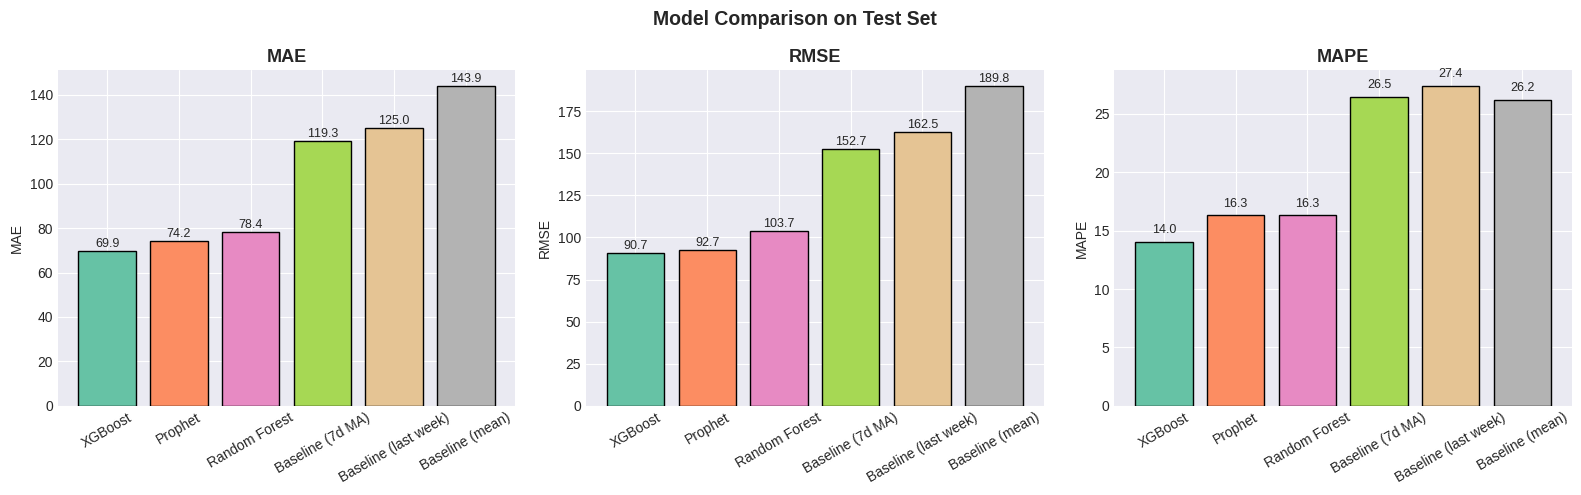

In [16]:
results_df = pd.DataFrame(results).T.round(2)
results_df = results_df.sort_values('RMSE')
print("\n=== MODEL COMPARISON (Hold-out test set) ===")
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'MAPE']
colors  = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df.index, results_df[metric], color=colors, edgecolor='black')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Prediction vs Actual Plots

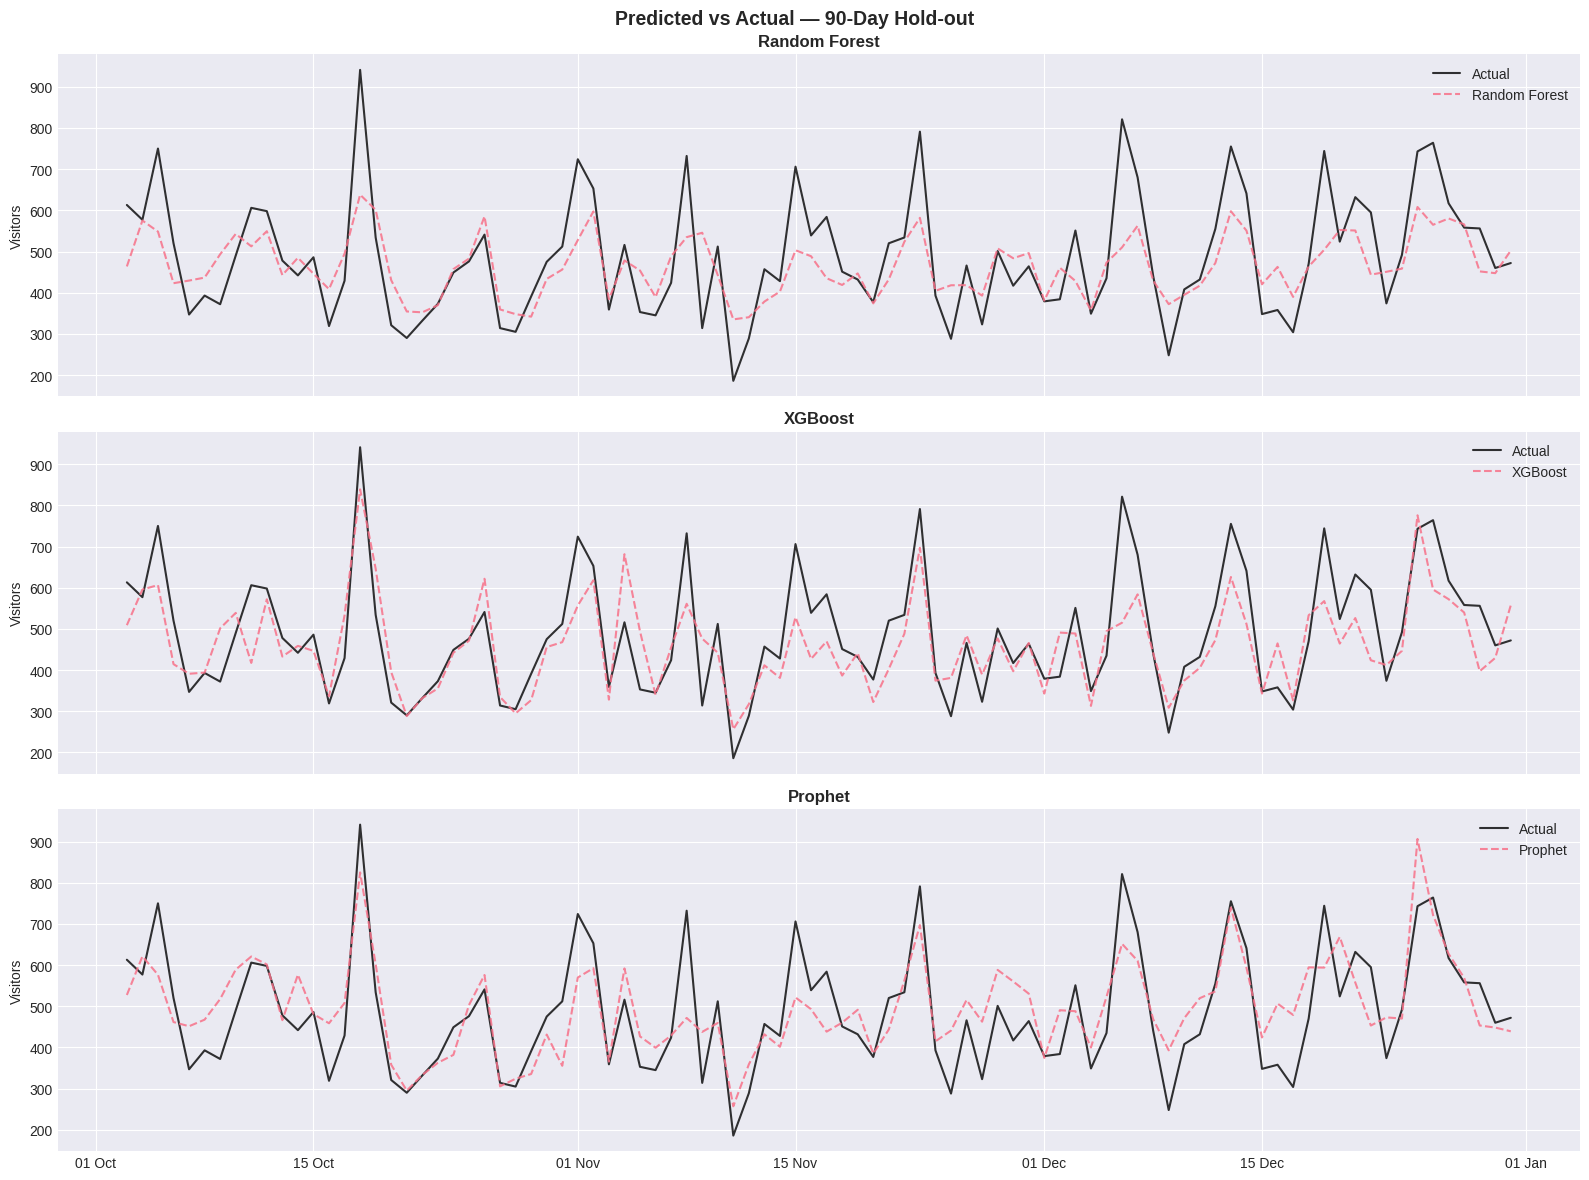

In [17]:
model_preds = {
    'Random Forest': rf_preds,
    'XGBoost':       xgb_preds,
    'Prophet':       prophet_preds,
}

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (name, preds) in zip(axes, model_preds.items()):
    ax.plot(test['date'], y_test.values, label='Actual', color='black', linewidth=1.5, alpha=0.8)
    ax.plot(test['date'], preds, label=name, linewidth=1.5, alpha=0.85, linestyle='--')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Visitors')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.suptitle('Predicted vs Actual — 90-Day Hold-out', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Importance (Best ML Model)

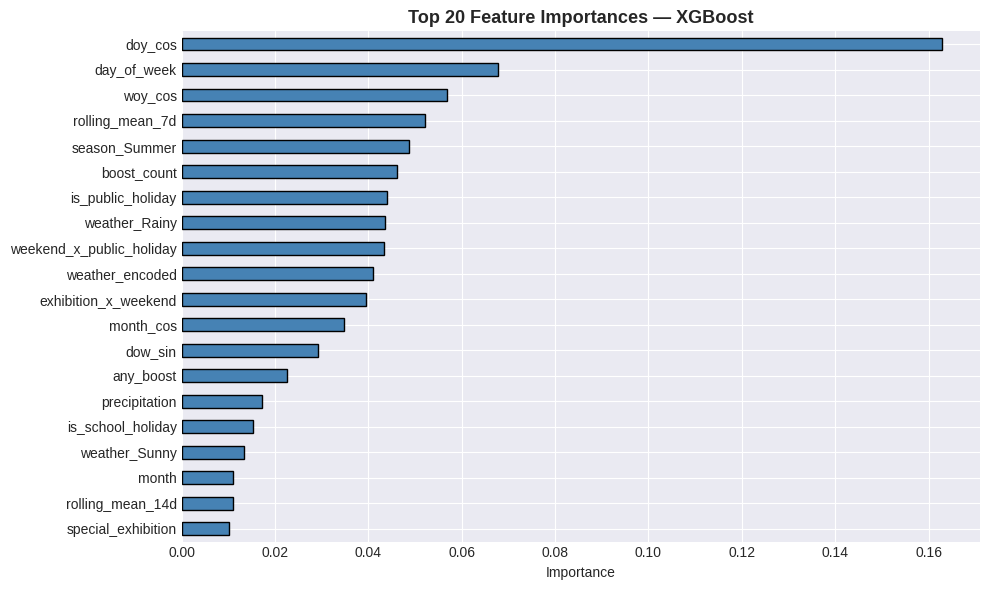

Best model: XGBoost

Top 10 features:
doy_cos                     0.1629
day_of_week                 0.0678
woy_cos                     0.0569
rolling_mean_7d             0.0522
season_Summer               0.0487
boost_count                 0.0460
is_public_holiday           0.0439
weather_Rainy               0.0435
weekend_x_public_holiday    0.0433
weather_encoded             0.0410


In [18]:
# Pick the better of RF vs XGBoost by RMSE
best_name = 'XGBoost' if results['XGBoost']['RMSE'] < results['Random Forest']['RMSE'] else 'Random Forest'
best_model = xgb_model if best_name == 'XGBoost' else rf

importances = pd.Series(best_model.feature_importances_, index=ALL_FEATURES)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20[::-1].plot(kind='barh', color='steelblue', edgecolor='black')
plt.title(f'Top 20 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(f"Best model: {best_name}")
print("\nTop 10 features:")
print(top20.head(10).round(4).to_string())

## 10. Prophet Components

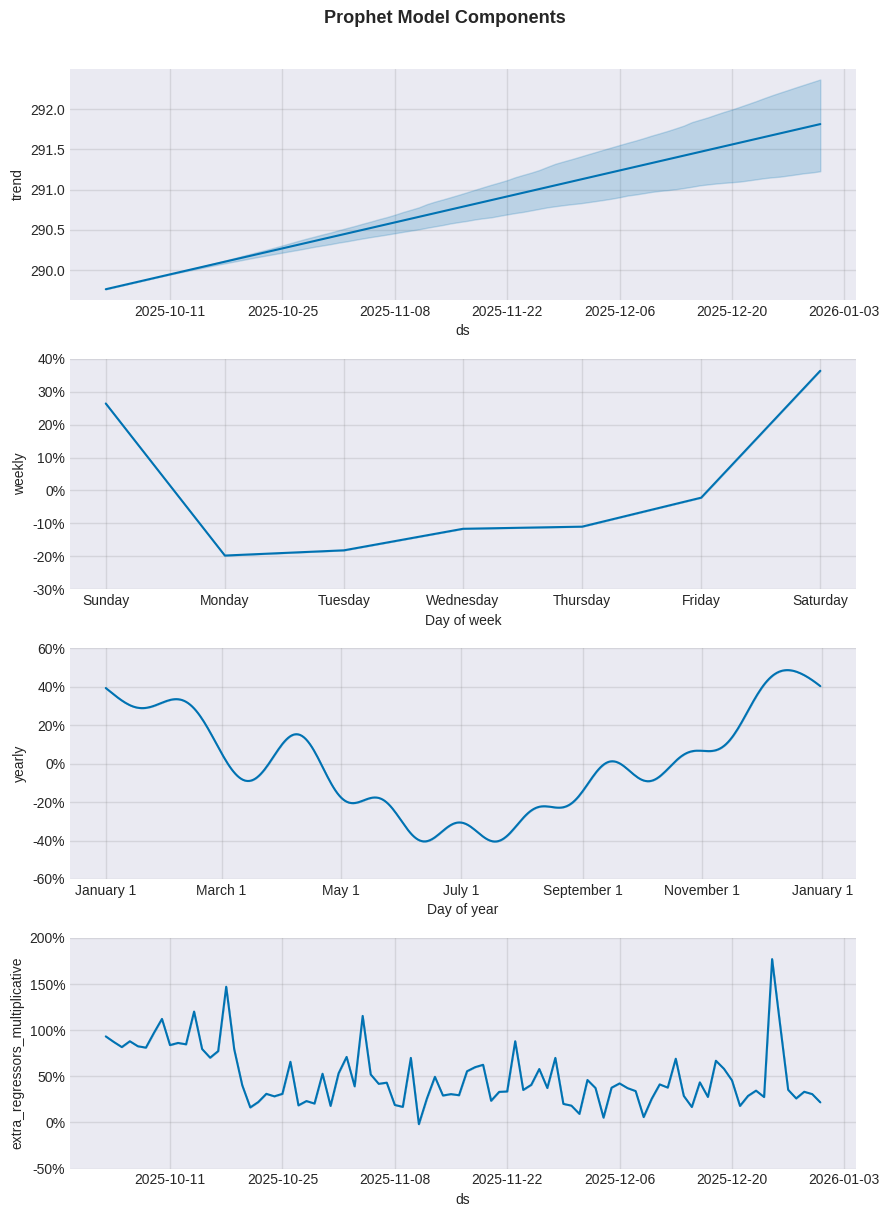

In [19]:
fig = prophet_model.plot_components(prophet_forecast)
fig.suptitle('Prophet Model Components', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Save Models

In [20]:
os.makedirs('../ml-pipeline/models', exist_ok=True)

# Save Random Forest
joblib.dump(rf, '../ml-pipeline/models/random_forest.joblib')

# Save XGBoost
xgb_model.save_model('../ml-pipeline/models/xgboost.json')

# Save Prophet
import pickle
with open('../ml-pipeline/models/prophet.pkl', 'wb') as f:
    pickle.dump(prophet_model, f)

# Save results summary
results_df.to_csv('../ml-pipeline/models/model_results.csv')

# Save feature list used
with open('../ml-pipeline/models/features.json', 'w') as f:
    json.dump({'features': ALL_FEATURES, 'best_model': best_name}, f, indent=2)

print("Models saved:")
print("  ml-pipeline/models/random_forest.joblib")
print("  ml-pipeline/models/xgboost.json")
print("  ml-pipeline/models/prophet.pkl")
print("  ml-pipeline/models/model_results.csv")
print("  ml-pipeline/models/features.json")

Models saved:
  ml-pipeline/models/random_forest.joblib
  ml-pipeline/models/xgboost.json
  ml-pipeline/models/prophet.pkl
  ml-pipeline/models/model_results.csv
  ml-pipeline/models/features.json


## 12. Summary

In [21]:
print("=" * 55)
print("MODELLING SUMMARY")
print("=" * 55)
print(f"""
Train period : {train['date'].min().date()} to {train['date'].max().date()} ({len(train)} days)
Test period  : {test['date'].min().date()}  to {test['date'].max().date()}  ({len(test)} days)
Features used: {len(ALL_FEATURES)}
""")
print(results_df.to_string())
print(f"""
Best model: {best_name}
  MAE  = {results[best_name]['MAE']:.1f} visitors
  RMSE = {results[best_name]['RMSE']:.1f} visitors
  R2   = {results[best_name]['R2']:.3f}
  MAPE = {results[best_name]['MAPE']:.1f}%
""")
print("=" * 55)

MODELLING SUMMARY

Train period : 2023-04-01 to 2025-10-02 (916 days)
Test period  : 2025-10-03  to 2025-12-31  (90 days)
Features used: 80

                         MAE    RMSE    R2   MAPE
XGBoost                69.87   90.66  0.62  14.04
Prophet                74.25   92.71  0.60  16.31
Random Forest          78.37  103.73  0.50  16.31
Baseline (7d MA)      119.27  152.74 -0.09  26.48
Baseline (last week)  125.04  162.54 -0.24  27.37
Baseline (mean)       143.91  189.82 -0.68  26.21

Best model: XGBoost
  MAE  = 69.9 visitors
  RMSE = 90.7 visitors
  R2   = 0.616
  MAPE = 14.0%



## Next Step

**`05_evaluation.ipynb`** — Deep-dive evaluation of the best model:
- Residual analysis
- Error breakdown by day/month/season
- SHAP explainability
- Prediction intervals
- Business-level interpretation